# Ch 17 Speeding Up Transformers

## Faster Inference Time Decoding

- For any model with a decoder component, it generates 1 token at time, sequentially. This is basically the same issue that RNNs had, but theres ways to get around this

### KV Caching

Each attn head in MHA layer computes scaled dot product attn: 
- Attention(Q,K,V) = softmax $(QK^T/ \sqrt{d_k})V$
- Remember d_k is a key dimensionaity, and in self-attn the QKV matrices are projections of the input sequence
- Row i has the i'th input token rep, and since MHA is masked, the token representation only influenced by tokens 1 to i, therefore adding a token just adds a row
- So just cache the matrices and only recompute the new row!
- Only cache KV: you dont need all of Q, since you only care about the last token output, so you only need the last row of Q

How does this work?
- Call decoder -> every KV matrix in every attn head in every MHA layer get saved to a cache ("prefill stage") : this step is dont normally (no shrunk Q)
- Each matrix has i rows, one per token, decoder outputs next token preds for 1 to i, you only care about i+1
- When you want the next token, just input token i+1, the first i tokens are already saved, Q,K,V projections give vectors [1 x d_k] for the new 1 token

**KV Cache memory management** is hard - changing size, variable length sequences, etc. PagedAttention in vLLM uses memory pages for efficient batching

Most HF transformers models support KV caching by default. The default cache is `transformers.DynamicCache`, but if you are using special attention like sparse attention other caches might be better

### Speculative Decoding

Idea: most tokens that an LLM generates are easy to predict. Example: "Your Python code is good, but there are syntax errors on lines 3 and 7." The only difficult words in this sentence would be the exact line numbers and Python, given the past tokens.

Use a fast model to predict the easy tokens - but which tokens are easy? You cant tell ahead of time.

Google researchers proposed this:
- For every generation step, pass the context containing tokens c_1 to c_t to the draft (small) model, and have it generate a sequence of n (d_t+1, d_t+n) more tokens.
    - You use KV caching and the small model and the generation is many times faster than the big model
- Then give the entire context + draft to the large (target) model [with kv caching, you only need to pass c_t, d_t+1, ...]
    - The target model processes n tokens in parallel rather than sequentially generating them
- For every input token, target outputs tokens o_1, o_t+n, where o_i = predicted next token (assuming each previous token is "correct")
- Now check the draft quality: if $d_i = o_{i-1}$, $\forall i \in [t+1, t+n]$, the draft was correct!
    - You can also append o_t+n, since it wasnt checked in the draft but is the target models next token prediction
- If the draft tokens are wrong? If the first draft token is wrong, the rest are useless, but if the draft got the first 3 right, you can keep the first 3+1 (target models prediction from the quality check)
    - Worst case scenario you still get 1 token from the target model, and all it cost you was a quick pass from the drafter

This is great but what about temperature and token probabilities? Models output logits for each next token, not one-hot vectors.
- You want your speculative decoding token distribution to be identical to the target model distribution

This is possible with **speculative sampling**, proved mathematicaly to yield identical token distributions!
- When generating draft token at idx i, draft model computes probability distribution $q_i(x)$ over the next possible token values (x), where the random choice = $d_i$
- The whole sequences goes through the target model, which gives probability distribution $p_i(x)$ over all possible next tokens -> DONT PICK AN OUTPUT YET
- For each draft tkn $d_i$, accept if $q_i(d_i) <= p_i(d_i)$, else, only accept with prob $q_i(d_i) / p_i(d_i)$, otherwise reject.
- If a draft is rejected, immediately stop, reject all the rest, sample the next token from the target model using an adjusted distrbution:
    - $p'_i(x) = max(0, p_i(x) - q_i(x)) / s_i$, with s_i as some constant of normalization
    - the purpose of this is to not oversample tokens the draft model can do


Draft length sequences: if too short, no speedup, if too long, most tokens will get rejected and slow you down
- Just tune this, mess around with it until you find one that works OR
- *Dynamic speculative decoding*: keep generating draft tokens until the drafter confidence falls beyond some threshold (this is the default)

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
# target_model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m",device_map="auto")
# draft_model = AutoModelForCausalLM.from_pretrained("facebook/opt-125m",device_map="auto")
# tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m")
# prompt = "Once upon a time there lived"
# inputs = tokenizer(prompt, return_tensors="pt").to(target_model.device)
# outputs = target_model.generate(**inputs, max_new_tokens=100, do_sample=True, temperature=1, assistant_model=draft_model)
# result = tokenizer.decode(outputs[0], skip_special_tokens=True)

Note: Practically I have seen this implemented with the Qwen3.6 27B model using an 0.8B drafter - drafter usually 10-20x smaller

MUST have the same tokenizer for the two models, otherwise your drafter and target are literally speaking different languages

Also, different tasks have differing levels of success:
- Summarization will speed up massively since its "easy" for llms
- Generating complex code in obscure programming languages while also writing comments in grammatically correct classical Latin will be very difficult for a drafter to do


### Main Approaches to Parallelize Decoding

**Draft and Verify**: speculative decoding and variants

**Decompose and fill**: break a problem into tasks, then do each task in parallel ("Generate 3 jokes, find which element in a list satisfies X, etc")

**Multiple token prediction**: Fine tune the LLM to predict >1 token at a time, which it can then check itself.
- Implement this by adding a <lookahead> token in training which tells the model theres multiple tokens here to predict

**One shot generation**: A one shot model produces the entire output in 1 parallel step - very fast, very prone to errors since you arent sequentially going token by token

**Masked generation**: Start with a fully masked sequence, eventually predict some words, and at each step, predict new and refine old tokens

**Edit based refinement**: use an editor model to edit the drafter output

## MHA Speed-ups

Multi Head Attention is the most expensive operation in LLMs, and speeding it up is very helpful for efficiency

softmax $(QK^T/ \sqrt{d_k})V$ -> expensive part is $QK^T$ -> this outputs an Lq x Lk matrix (length of query x length of key)
- For self attn, Lk = Lq since its the same sequence, so for very long sequences the matrix grows into a massive square matrix

### Sparse Attention

For normal masked MHA, every query looks at every key up to its position. What if we changed that?

#### Sparse Transformers
Decoder only, 2019, OpenAI
- Half the attn heads only look at the last n (like n=256) local tokens, while the other half only attends to every n tokens globally. 
- N is called the stride, usually pick n = root(max_seq_len)

Strided sparse attention - both local and global masks slide smoothly with the query tokens - works good for imgs/periodic data

Fixed sparse attention - query split into blocks of n token length, local mask is the querys block, global mask is the last key token of every block. Better for text

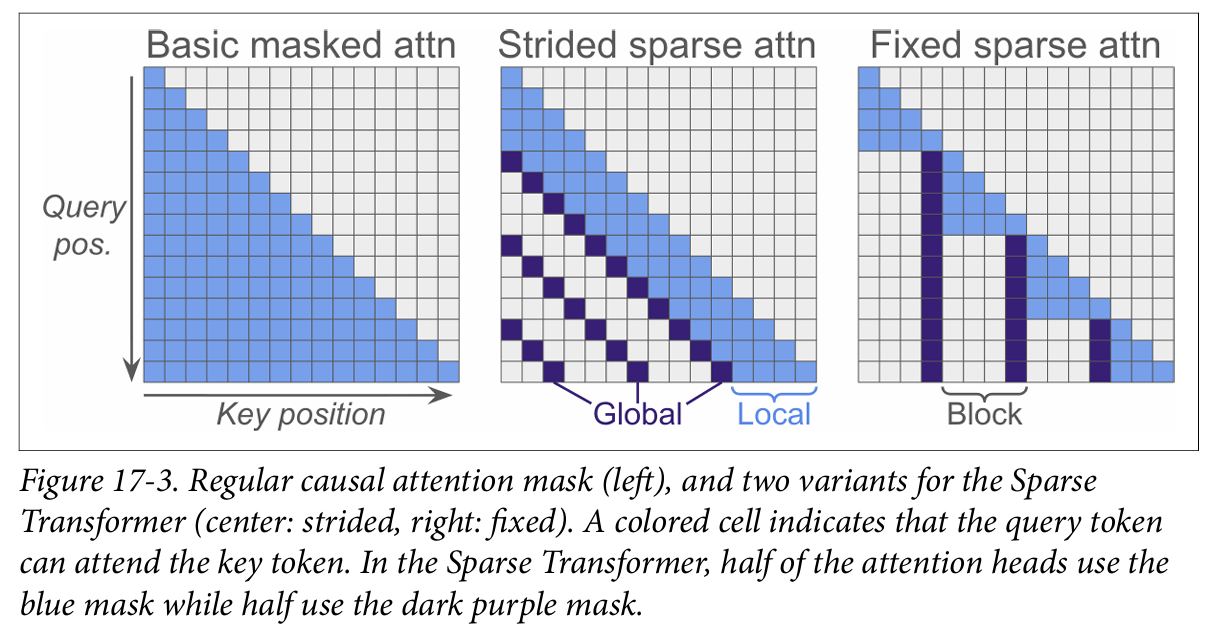

Each query only sees n_local_tokens and position_idx / n_global_tokens versus position_idx tokens - much better efficiency

But now information has to go to a global token to get somewhere, so there are bottleneck issues or anything that needs very specific details to be known everywhere

#### Longformer
Encoder-only, 2020

- Attn masks now look at past and future tokens, symmetric about main diagonal of matrix
- Uses a standard sliding window of local attention, centered on the query token index, usually about a 512 token window (meant to be used on LONG documents)

Important: uses a fixed number of global tokens
- For classification, uses [CLS] as only global token which attends to / is attended to by every token
- For question answering, make every question token global

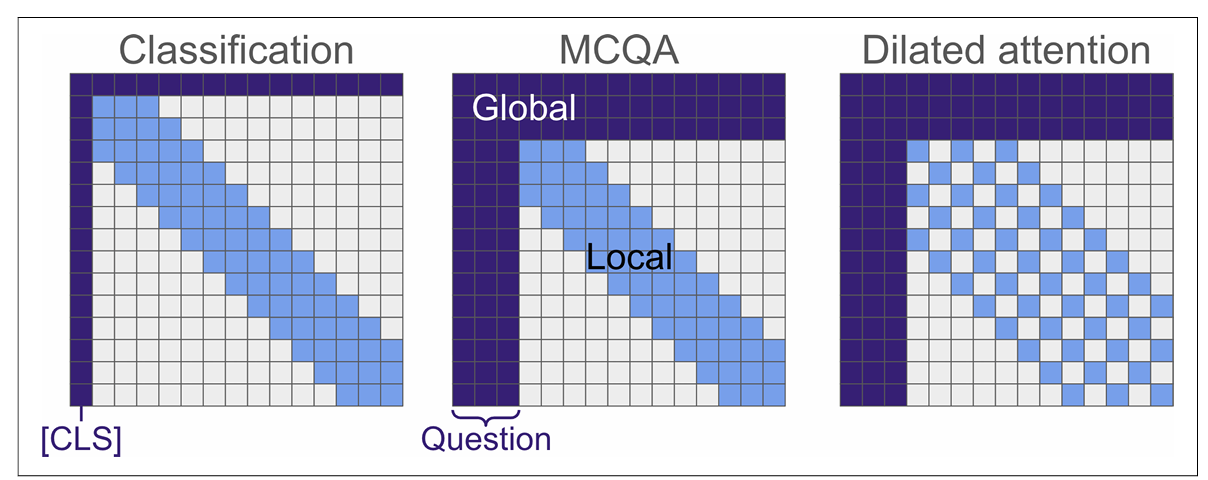

Another idea in the original paper: use short windows at low layers, long windows at high layers -> low levels focus on small patterns, dont need massive attention windows

Also proposed dilated windows like WaveNet to expand windows even more

#### BigBird
Google, 2020 -> like the longformer - dilation + random attention

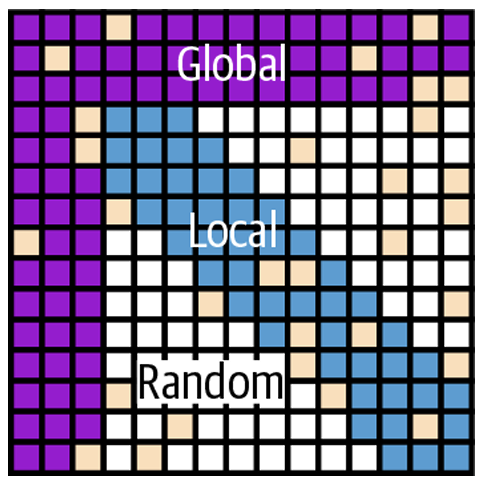

Random Attention offers good theoretical guarantees: scales to long sequences linearly, and just as expressive as original architecture

Paper also showed BigBird can execute any function (as long as you feed itself its outputs). However, it needs more layers, because information needs to travel through a lot of random tokens to get everywhere

Every attn head uses a different random mask, and the random mask is constant

Generally better than the LongFormer on long context


#### Routing Transformer
Google, 2020

Previous mechanisms chose attentions based on positions, this one groups Q and K tokens into clusters, then computes scaled dot-product attn for each cluster separately. 

Clustering is based on similarity scores btwn tokens, but tokens carry positional encoding info, so more similar tokens are already more likely to be close

Routing Transformer does mini-batch k-means, with each attn head having k centroids [each centroid is a learned vector]

Each centroid is updated with an EMA of the closest s tokens during training

Use k close to root(max_seq_len) - but routing transformers are hard to implement, not as popular


### Approximate Attention

## MoE

## Fast Training and Tuning